In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [14]:
df=pd.read_csv('Mall_Customers (3).csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [15]:
df.drop('CustomerID',axis=1,inplace=True)
df.drop('Gender',axis=1,inplace=True)
df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


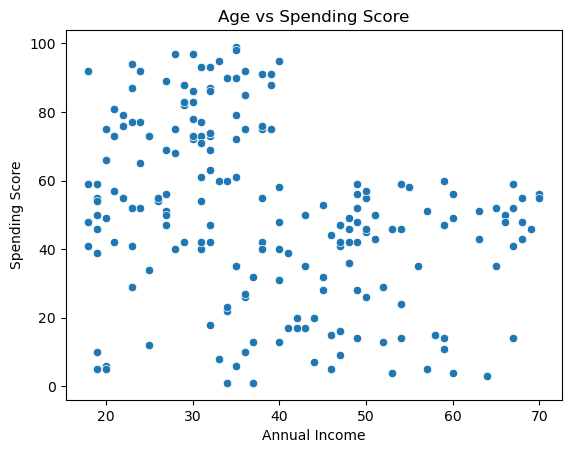

In [22]:
plt.Figure(figsize=(10,10))
sns.scatterplot(x='Age',y='Spending Score (1-100)',data=df)
plt.title('Age vs Spending Score')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

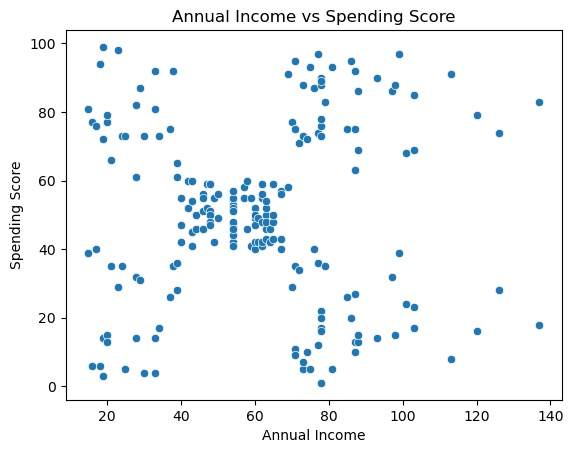

In [21]:
plt.Figure(figsize=(10,10))
sns.scatterplot(x='Annual Income (k$)',y='Spending Score (1-100)',data=df)
plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

In [23]:
print("skewnwess of Age",df['Age'].skew())
print("skewnwess of Annual Income",df['Annual Income (k$)'].skew())
print("skewnwess of Spending Score",df['Spending Score (1-100)'].skew())

skewnwess of Age 0.48556885096681657
skewnwess of Annual Income 0.3218425498619055
skewnwess of Spending Score -0.047220201374263374


In [24]:
def skewness_name(skewnwss):
    if skewnwss>0:
        return 'right skewed'
    else:
        return 'left skewed'
print("skewnwess of Age",skewness_name(df['Age'].skew()))
print("skewnwess of Annual Income",skewness_name(df['Annual Income (k$)'].skew()))
print("skewnwess of Spending Score",skewness_name(df['Spending Score (1-100)'].skew()))

skewnwess of Age right skewed
skewnwess of Annual Income right skewed
skewnwess of Spending Score left skewed


In [25]:
kmeans=KMeans(n_clusters=5, random_state=42)
kmeans.fit(df)
df['Cluster']=kmeans.labels_
df.head()


c:\Users\charm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,19,15,39,2
1,21,15,81,2
2,20,16,6,0
3,23,16,77,2
4,31,17,40,0


In [26]:
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)

c:\Users\charm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\charm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\charm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\charm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

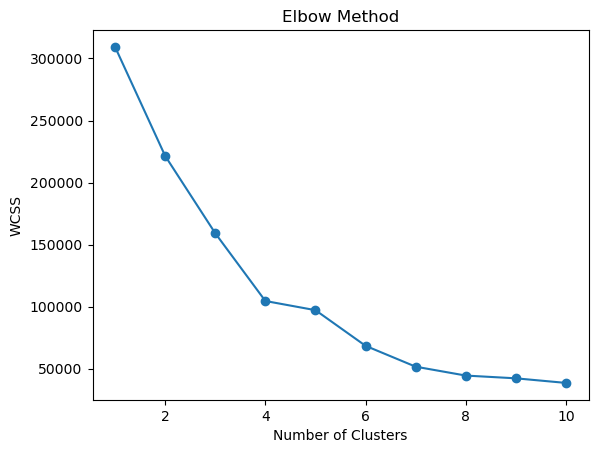

In [27]:
plt.plot(range(1,11), wcss,marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

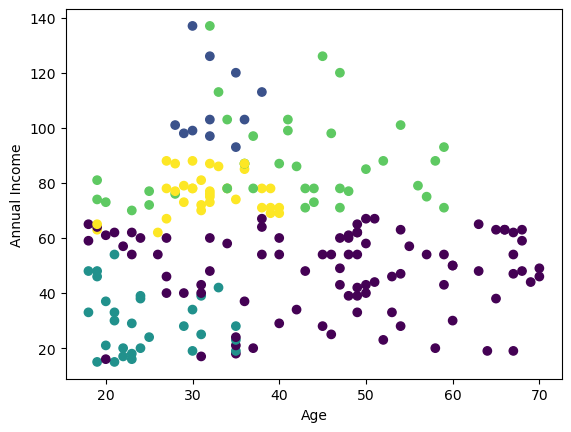

In [28]:
plt.scatter(df['Age'],df['Annual Income (k$)'],c=df['Cluster'])
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.show()

In [29]:
df.to_csv('Mall_Customers (4).csv',index=False)